# EUR/USD 4-Hour Historical Data — Dukascopy Download Notebook

This notebook downloads **EUR/USD 1-hour BID data** from Dukascopy, combines the yearly chunks, converts the data to **4-hour OHLCV candles**, validates the result, and saves the final dataset as:

`EURUSD_4H.csv`

## Project standard

- Pair: EUR/USD
- Source: Dukascopy
- Start: 2009-01-01
- End: 2026-09-02
- Source frequency: 1 Hour
- Final frequency: 4 Hours
- Timezone: UTC
- Offer side: BID
- Columns: Open, High, Low, Close, Volume


In [2]:
import sys
import platform
import os

print("Python version:", sys.version)
print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("Operating system:", platform.system())
print("OS version:", platform.version())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Current working directory:", os.getcwd())

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Python executable: C:\Users\hamostafa\AppData\Local\anaconda3\envs\py3-math\python.exe
Platform: Windows-11-10.0.26200-SP0
Operating system: Windows
OS version: 10.0.26200
Machine: AMD64
Processor: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
Current working directory: D:\hossam\Git\GitHub\math\notebooks\TimeSeries\00_Project


## 1. Install required packages

Run this cell once if `dukascopy-python` is not already installed.

In [4]:
#First Time only
# !pip install dukascopy-python pandas matplotlib

## 2. Import libraries

In [1]:
from datetime import datetime
from time import sleep

import pandas as pd
import matplotlib.pyplot as plt
import dukascopy_python

from dukascopy_python.instruments import (
    INSTRUMENT_FX_MAJORS_EUR_USD
)

## 3. Define the EUR/USD download settings

We will download **1-hour candles** and later resample them into **4-hour candles**.

In [3]:
START_DATE = datetime(2009, 1, 1)
END_DATE = datetime(2026, 9, 2)

instrument = INSTRUMENT_FX_MAJORS_EUR_USD
interval = dukascopy_python.INTERVAL_HOUR_1
offer_side = dukascopy_python.OFFER_SIDE_BID

print("Start date :", START_DATE)
print("End date   :", END_DATE)
print("Interval   : 1 Hour")
print("Offer side : BID")

Start date : 2009-01-01 00:00:00
End date   : 2026-09-02 00:00:00
Interval   : 1 Hour
Offer side : BID


## 4. Download the data year by year

Downloading in yearly chunks is safer than requesting the entire 2009–2026 period in one call.

In [4]:
all_data = []

for year in range(2009, 2027):

    chunk_start = datetime(year, 1, 1)

    if year == 2026:
        chunk_end = END_DATE
    else:
        chunk_end = datetime(year + 1, 1, 1)

    print(
        f"Downloading {chunk_start.date()} "
        f"to {chunk_end.date()}..."
    )

    df = dukascopy_python.fetch(
        instrument=instrument,
        interval=interval,
        offer_side=offer_side,
        start=chunk_start,
        end=chunk_end,
        max_retries=5
    )

    if df is not None and not df.empty:
        all_data.append(df)
        print(f"Downloaded {len(df):,} rows")
    else:
        print("No data returned")

    sleep(1)

print('Download Process finished')

Downloaded 6,433 rows
Downloaded 6,928 rows
Downloaded 8,734 rows
Downloaded 8,675 rows
Downloaded 8,708 rows
Downloaded 7,109 rows
Downloaded 6,245 rows
Downloaded 6,247 rows
Downloaded 6,224 rows
Downloaded 6,226 rows
Downloaded 6,228 rows
Downloaded 6,251 rows
Downloaded 6,241 rows
Downloaded 6,241 rows
Downloaded 6,225 rows
Downloaded 6,250 rows
Downloaded 6,226 rows
Downloaded 4,153 rows


## 5. Combine all downloaded yearly chunks

In [5]:
eurusd_h1 = pd.concat(all_data)

eurusd_h1.head()

,open,high,low,close,volume
timestamp,,,,,
2008-12-31 21:00:00+00:00,1.39658,1.39945,1.39574,1.39692,13453.8
2008-12-31 22:00:00+00:00,1.39695,1.39945,1.39657,1.39707,20813.9
2008-12-31 23:00:00+00:00,1.39707,1.39765,1.39685,1.39746,22929.3
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39682,9641.1
2009-01-01 01:00:00+00:00,1.39684,1.39736,1.39674,1.39710,5882.8


## 6. Sort the time index

In [6]:
eurusd_h1 = eurusd_h1.sort_index()

eurusd_h1.head()

,open,high,low,close,volume
timestamp,,,,,
2008-12-31 21:00:00+00:00,1.39658,1.39945,1.39574,1.39692,13453.8
2008-12-31 22:00:00+00:00,1.39695,1.39945,1.39657,1.39707,20813.9
2008-12-31 23:00:00+00:00,1.39707,1.39765,1.39685,1.39746,22929.3
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39682,9641.1
2009-01-01 01:00:00+00:00,1.39684,1.39736,1.39674,1.39710,5882.8


## 7. Remove duplicate timestamps

This is a safety check because yearly chunks are being combined.

In [7]:
eurusd_h1 = eurusd_h1[
    ~eurusd_h1.index.duplicated(keep="first")
]

print("Duplicate timestamps:", eurusd_h1.index.duplicated().sum())

Duplicate timestamps: 0


## 8. Make sure timestamps use UTC

In [8]:
if eurusd_h1.index.tz is None:
    eurusd_h1.index = eurusd_h1.index.tz_localize("UTC")
else:
    eurusd_h1.index = eurusd_h1.index.tz_convert("UTC")

print("Timezone:", eurusd_h1.index.tz)

Timezone: UTC


## 9. Rename the columns

The package normally returns lowercase column names.  
We will standardize them to:

`Open, High, Low, Close, Volume`

In [9]:
eurusd_h1 = eurusd_h1.rename(
    columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume"
    }
)

eurusd_h1.index.name = "DateTime"

eurusd_h1.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 21:00:00+00:00,1.39658,1.39945,1.39574,1.39692,13453.8
2008-12-31 22:00:00+00:00,1.39695,1.39945,1.39657,1.39707,20813.9
2008-12-31 23:00:00+00:00,1.39707,1.39765,1.39685,1.39746,22929.3
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39682,9641.1
2009-01-01 01:00:00+00:00,1.39684,1.39736,1.39674,1.39710,5882.8


## 10. Inspect the 1-hour dataset

In [10]:
print("Shape:", eurusd_h1.shape)
print("Start:", eurusd_h1.index.min())
print("End:", eurusd_h1.index.max())

eurusd_h1.info()

Shape: (119331, 5)
Start: 2008-12-31 21:00:00+00:00
End: 2026-09-01 21:00:00+00:00
<class 'pandas.DataFrame'>
DatetimeIndex: 119331 entries, 2008-12-31 21:00:00+00:00 to 2026-09-01 21:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    119331 non-null  float64
 1   High    119331 non-null  float64
 2   Low     119331 non-null  float64
 3   Close   119331 non-null  float64
 4   Volume  119331 non-null  float64
dtypes: float64(5)
memory usage: 5.5 MB


## 22. Save 1-hour dataset

In [11]:
eurusd_h1.to_csv("Data/EURUSD_H1.csv")

print("Saved: Data/EURUSD_H1.csv")

Saved: EURUSD_H1.csv


# Convert H1 data to H4 data

For OHLCV resampling:

- **Open** → first value
- **High** → maximum value
- **Low** → minimum value
- **Close** → last value
- **Volume** → sum


In [12]:
eurusd_4h = eurusd_h1.resample(
    "4h",
    origin="start_day",
    label="left",
    closed="left"
).agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

eurusd_4h.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65


## 11. Remove empty weekend periods

Forex does not trade continuously through the weekend.

We remove empty resampled periods instead of forward-filling them.

In [13]:
eurusd_4h = eurusd_4h.dropna(
    subset=["Open", "High", "Low", "Close"]
)

eurusd_4h.head(10)

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65
2009-01-01 16:00:00+00:00,1.40684,1.40706,1.39600,1.39723,80080.30
2009-01-01 20:00:00+00:00,1.39725,1.40515,1.39680,1.39974,39683.10
2009-01-02 00:00:00+00:00,1.40013,1.40255,1.38590,1.38865,39827.00
2009-01-02 04:00:00+00:00,1.38860,1.39050,1.38390,1.38970,40203.80


## 12. Validate the date range

In [14]:
print("Start :", eurusd_4h.index.min())
print("End   :", eurusd_4h.index.max())
print("Rows  :", len(eurusd_4h))

Start : 2008-12-31 20:00:00+00:00
End   : 2026-09-01 20:00:00+00:00
Rows  : 30561


## 13. Check the time gaps

The most common interval should be:

`0 days 04:00:00`

Longer gaps can occur because of weekends or market closures.

In [15]:
eurusd_4h.index.to_series().diff().value_counts().head(10)

DateTime
0 days 04:00:00    29803
2 days 00:00:00      702
1 days 20:00:00       25
0 days 16:00:00        9
1 days 00:00:00        7
0 days 08:00:00        4
3 days 00:00:00        4
1 days 04:00:00        2
2 days 16:00:00        2
1 days 12:00:00        1
Name: count, dtype: int64

## 14. Check observations per year

In [16]:
eurusd_4h.groupby(
    eurusd_4h.index.year
).size()

DateTime
2008       1
2009    1645
2010    1761
2011    2184
2012    2174
2013    2185
2014    1813
2015    1609
2016    1612
2017    1609
2018    1610
2019    1610
2020    1615
2021    1612
2022    1612
2023    1609
2024    1616
2025    1610
2026    1074
dtype: int64

## 15. Check missing values

In [17]:
eurusd_4h.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## 16. Check distinct available years

In [18]:
eurusd_4h.index.year.unique()

Index([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025, 2026],
      dtype='int32', name='DateTime')

## 17. Check distinct months in 2025

In [19]:
eurusd_4h.loc["2025"].index.month_name().unique()

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='str', name='DateTime')

## 18. Display only 2025

In [20]:
eurusd_4h.loc["2025"].head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2025-01-01 20:00:00+00:00,1.03503,1.03577,1.03462,1.03507,5890.59
2025-01-02 00:00:00+00:00,1.03508,1.03740,1.03442,1.03715,14326.72
2025-01-02 04:00:00+00:00,1.03716,1.03756,1.03599,1.03627,18505.16
2025-01-02 08:00:00+00:00,1.03628,1.03709,1.03135,1.03321,39017.84
2025-01-02 12:00:00+00:00,1.03321,1.03342,1.02725,1.02741,79600.81


## 19. Display one month

Example: January 2025.

In [21]:
eurusd_4h.loc["2025-01"].head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2025-01-01 20:00:00+00:00,1.03503,1.03577,1.03462,1.03507,5890.59
2025-01-02 00:00:00+00:00,1.03508,1.03740,1.03442,1.03715,14326.72
2025-01-02 04:00:00+00:00,1.03716,1.03756,1.03599,1.03627,18505.16
2025-01-02 08:00:00+00:00,1.03628,1.03709,1.03135,1.03321,39017.84
2025-01-02 12:00:00+00:00,1.03321,1.03342,1.02725,1.02741,79600.81


## 20. Filter between two dates using a boolean mask

In [22]:
eurusd_4h[
    (eurusd_4h.index >= "2025-01-01") &
    (eurusd_4h.index <= "2025-03-31")
].head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2025-01-01 20:00:00+00:00,1.03503,1.03577,1.03462,1.03507,5890.59
2025-01-02 00:00:00+00:00,1.03508,1.03740,1.03442,1.03715,14326.72
2025-01-02 04:00:00+00:00,1.03716,1.03756,1.03599,1.03627,18505.16
2025-01-02 08:00:00+00:00,1.03628,1.03709,1.03135,1.03321,39017.84
2025-01-02 12:00:00+00:00,1.03321,1.03342,1.02725,1.02741,79600.81


## 21. Plot EUR/USD 4-hour closing price for 2025

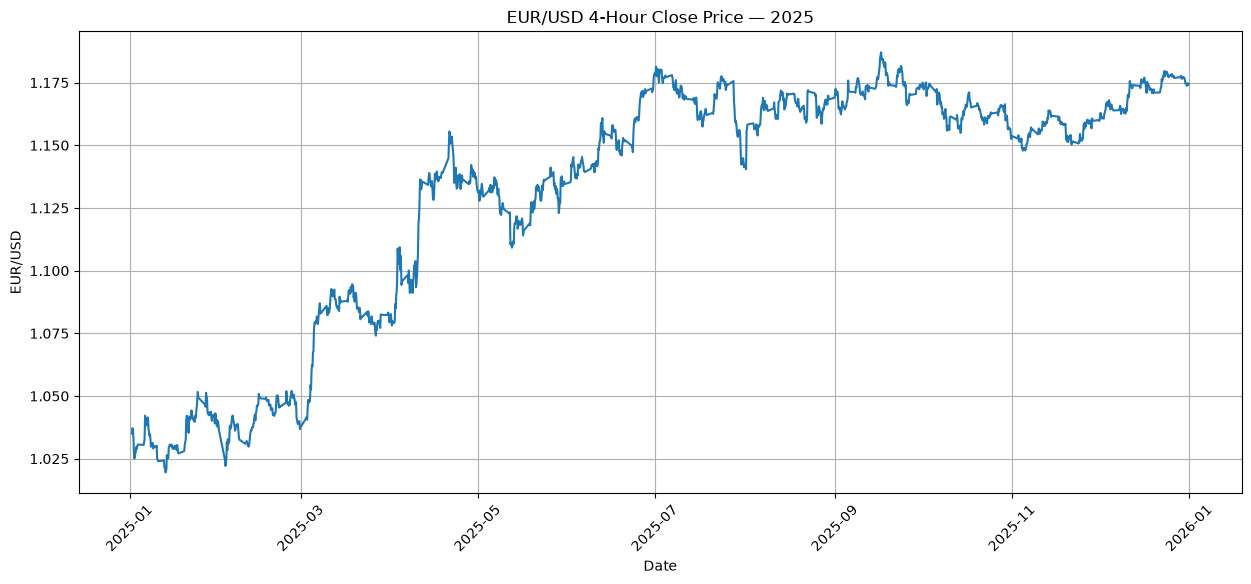

In [23]:
eurusd_2025 = eurusd_4h.loc["2025"]

plt.figure(figsize=(15, 6))

plt.plot(
    eurusd_2025.index,
    eurusd_2025["Close"]
)

plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.title("EUR/USD 4-Hour Close Price — 2025")

plt.xticks(rotation=45)
plt.grid()

plt.show()

## 22. Save the final clean 4-hour dataset

In [24]:
eurusd_4h.to_csv("Data/EURUSD_H4.csv")

print("Saved: Data/EURUSD_H4.csv")

Saved: Data/EURUSD_H4.csv


## 23. Load the saved file later

In future notebooks, you can load the clean dataset directly without downloading it again.

In [25]:
eurusd = pd.read_csv(
    "Data/EURUSD_H4.csv",
    parse_dates=["DateTime"],
    index_col="DateTime"
)

eurusd.head()

,Open,High,Low,Close,Volume
DateTime,,,,,
2008-12-31 20:00:00+00:00,1.39658,1.39945,1.39574,1.39746,57197.00
2009-01-01 00:00:00+00:00,1.39734,1.39754,1.39672,1.39702,38071.80
2009-01-01 04:00:00+00:00,1.39716,1.39740,1.39663,1.39700,67849.25
2009-01-01 08:00:00+00:00,1.39708,1.40370,1.39700,1.40367,128442.75
2009-01-01 12:00:00+00:00,1.40346,1.40707,1.40346,1.40682,128985.65


# Final validation block

Run this block whenever you want a quick health check of the dataset.

In [26]:
print("Shape:")
print(eurusd_4h.shape)

print("\nDate Range:")
print(eurusd_4h.index.min())
print(eurusd_4h.index.max())

print("\nDuplicate Dates:")
print(eurusd_4h.index.duplicated().sum())

print("\nMissing Values:")
print(eurusd_4h.isna().sum())

print("\nMost Common Time Gaps:")
print(
    eurusd_4h.index
    .to_series()
    .diff()
    .value_counts()
    .head(10)
)

print("\nObservations Per Year:")
print(
    eurusd_4h.groupby(
        eurusd_4h.index.year
    ).size()
)

Shape:
(30561, 5)

Date Range:
2008-12-31 20:00:00+00:00
2026-09-01 20:00:00+00:00

Duplicate Dates:
0

Missing Values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Most Common Time Gaps:
DateTime
0 days 04:00:00    29803
2 days 00:00:00      702
1 days 20:00:00       25
0 days 16:00:00        9
1 days 00:00:00        7
0 days 08:00:00        4
3 days 00:00:00        4
1 days 04:00:00        2
2 days 16:00:00        2
1 days 12:00:00        1
Name: count, dtype: int64

Observations Per Year:
DateTime
2008       1
2009    1645
2010    1761
2011    2184
2012    2174
2013    2185
2014    1813
2015    1609
2016    1612
2017    1609
2018    1610
2019    1610
2020    1615
2021    1612
2022    1612
2023    1609
2024    1616
2025    1610
2026    1074
dtype: int64


# Summary

This notebook performs the complete workflow:

1. Download EUR/USD 1-hour BID data from Dukascopy.
2. Download yearly chunks from 2009 to 2026.
3. Combine and sort the data.
4. Remove duplicate timestamps.
5. Standardize timestamps to UTC.
6. Rename OHLCV columns.
7. Resample H1 candles into H4 candles.
8. Remove empty weekend periods.
9. Validate frequency, missing values, years, and date range.
10. Save the final dataset as `EURUSD_4H.csv`.

You can now use `EURUSD_4H.csv` in your Time Series lessons and EUR/USD analysis project.
